# Stationarity in Time Series: Tests and Transformations

## Overview

Stationarity is the foundational assumption of most time series models (ARIMA, VAR, cointegration). A stationary series has a constant mean, constant variance, and autocorrelation structure that depends only on the lag — not on when in the series you are.

| Property | Stationary | Non-stationary |
|---|---|---|
| Mean | Constant over time | Drifts or trends |
| Variance | Constant over time | Changes over time |
| Autocorrelation | Depends only on lag | Depends on both lag and time position |

**Two types of non-stationarity:**
- **Trend-stationary:** Deterministic trend — remove by detrending (regression on time)
- **Difference-stationary (unit root):** Stochastic trend — remove by differencing

ARIMA handles difference-stationarity via the `d` parameter. Getting `d` wrong leads to model misspecification.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Long-term invertebrate abundance before modelling trends |
| **Healthcare** | Weekly ED admissions before building a forecasting model |
| **Finance** | Asset prices (non-stationary); returns (typically stationary) |
| **Insurance** | Monthly claims frequency before ARIMA forecasting |

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"package 'forecas

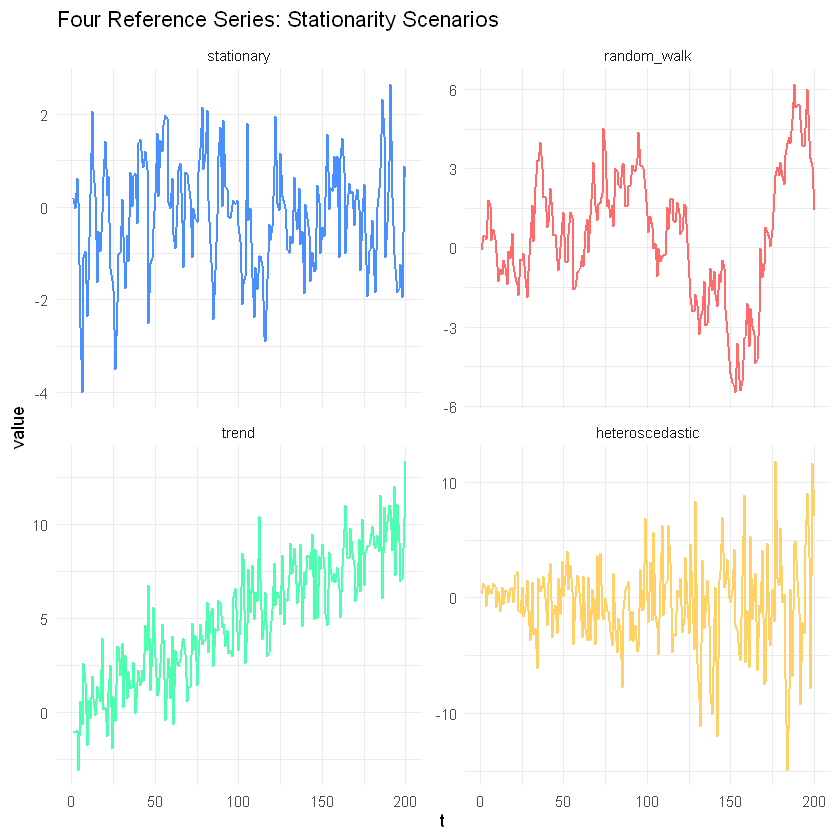

In [1]:
library(tidyverse)
library(ggplot2)
library(tseries)    # adf.test(), kpss.test()
library(urca)       # ur.df(), ur.kpss() — explicit deterministic term control
library(forecast)   # ndiffs(), nsdiffs()
library(patchwork)

set.seed(42)
n <- 200
t <- 1:n

# ── Four reference series ────────────────────────────────────────────────────
series_stationary  <- arima.sim(list(ar = 0.6), n = n)             # AR(1), stationary
series_rw          <- cumsum(rnorm(n))                              # random walk (unit root)
series_trend       <- 0.05 * t + rnorm(n, 0, 1.5)                  # deterministic trend
series_hetero      <- rnorm(n, 0, 1 + 0.03 * t)                    # growing variance

tibble(t=t, stationary=as.numeric(series_stationary),
       random_walk=series_rw, trend=series_trend,
       heteroscedastic=series_hetero) %>%
  pivot_longer(-t, names_to="series", values_to="value") %>%
  mutate(series = factor(series,
    levels=c("stationary","random_walk","trend","heteroscedastic"))) %>%
  ggplot(aes(x=t, y=value, color=series)) +
  geom_line(linewidth=0.7) +
  facet_wrap(~series, scales="free_y", ncol=2) +
  scale_color_manual(values=c("#4a8fff","#ff6b6b","#4fffb0","#ffd166")) +
  labs(title="Four Reference Series: Stationarity Scenarios") +
  theme_minimal() + theme(legend.position="none")

---

## Augmented Dickey-Fuller (ADF) Test

**H₀:** The series has a unit root (non-stationary)  
**H₁:** The series is stationary  
p < 0.05 → reject H₀ → evidence of stationarity

In [2]:
series_list <- list(
  stationary      = series_stationary,
  random_walk     = series_rw,
  trend           = series_trend,
  heteroscedastic = series_hetero
)

adf_results <- map_dfr(names(series_list), function(nm) {
  res <- tseries::adf.test(series_list[[nm]], alternative="stationary")
  tibble(series   = nm,
         ADF_stat = round(res$statistic, 4),
         ADF_p    = round(res$p.value, 4),
         verdict  = ifelse(res$p.value < 0.05, "Stationary", "Non-stationary"))
})
print(adf_results)

# ── urca gives explicit control over deterministic components ─────────────────
# type="none":  no constant or trend (rarely appropriate)
# type="drift": constant only
# type="trend": constant + linear trend (use when series has a visible trend)
adf_urca <- urca::ur.df(series_trend, type="trend", selectlags="AIC")
summary(adf_urca)
# Compare test statistic to critical values at 1%, 5%, 10%
# More negative than 5% critical value → stationary (reject unit root)

Warning message in tseries::adf.test(series_list[[nm]], alternative = "stationary"):
"p-value smaller than printed p-value"
Warning message in tseries::adf.test(series_list[[nm]], alternative = "stationary"):
"p-value smaller than printed p-value"
Warning message in tseries::adf.test(series_list[[nm]], alternative = "stationary"):
"p-value smaller than printed p-value"


# A tibble: 4 × 4
  series          ADF_stat ADF_p verdict       
  <chr>              <dbl> <dbl> <chr>         
1 stationary         -5.59 0.01  Stationary    
2 random_walk        -2.22 0.484 Non-stationary
3 trend              -5.89 0.01  Stationary    
4 heteroscedastic    -6.16 0.01  Stationary    



############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.5566 -0.9189 -0.0243  1.1134  4.8415 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.006590   0.230587   0.029    0.977    
z.lag.1     -0.944801   0.101999  -9.263  < 2e-16 ***
tt           0.047266   0.005448   8.676 1.65e-15 ***
z.diff.lag  -0.046066   0.072406  -0.636    0.525    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.603 on 194 degrees of freedom
Multiple R-squared:  0.4911,	Adjusted R-squared:  0.4832 
F-statistic:  62.4 on 3 and 194 DF,  p-value: < 2.2e-16


Value of test-statistic is: -9.2628 28.8774 42.9113 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.99 -3.43 -3.13
phi2  6.2

---

## KPSS Test

**H₀:** The series is stationary  
**H₁:** The series has a unit root  
p < 0.05 → reject H₀ → evidence of non-stationarity

ADF and KPSS have **opposite nulls** — always use them together.

In [3]:
kpss_results <- map_dfr(names(series_list), function(nm) {
  res <- tseries::kpss.test(series_list[[nm]], null="Level")
  tibble(series    = nm,
         KPSS_stat = round(res$statistic, 4),
         KPSS_p    = round(res$p.value, 4),
         verdict   = ifelse(res$p.value > 0.05, "Stationary", "Non-stationary"))
})
print(kpss_results)

# ── Combine ADF and KPSS verdicts ─────────────────────────────────────────────
left_join(adf_results, kpss_results, by="series", suffix=c("_ADF","_KPSS")) %>%
  select(series, verdict_ADF, verdict_KPSS) %>%
  mutate(conclusion = case_when(
    verdict_ADF=="Stationary"     & verdict_KPSS=="Stationary"     ~ "Stationary",
    verdict_ADF=="Non-stationary" & verdict_KPSS=="Non-stationary" ~ "Non-stationary (unit root)",
    verdict_ADF=="Stationary"     & verdict_KPSS=="Non-stationary" ~ "Trend-stationary — detrend",
    verdict_ADF=="Non-stationary" & verdict_KPSS=="Stationary"     ~ "Ambiguous — increase lags"
  )) %>% print()

Warning message in tseries::kpss.test(series_list[[nm]], null = "Level"):
"p-value greater than printed p-value"
Warning message in tseries::kpss.test(series_list[[nm]], null = "Level"):
"p-value greater than printed p-value"
Warning message in tseries::kpss.test(series_list[[nm]], null = "Level"):
"p-value smaller than printed p-value"
Warning message in tseries::kpss.test(series_list[[nm]], null = "Level"):
"p-value greater than printed p-value"


# A tibble: 4 × 4
  series          KPSS_stat KPSS_p verdict       
  <chr>               <dbl>  <dbl> <chr>         
1 stationary         0.0934   0.1  Stationary    
2 random_walk        0.290    0.1  Stationary    
3 trend              3.90     0.01 Non-stationary
4 heteroscedastic    0.0887   0.1  Stationary    
# A tibble: 4 × 4
  series          verdict_ADF    verdict_KPSS   conclusion                
  <chr>           <chr>          <chr>          <chr>                     
1 stationary      Stationary     Stationary     Stationary                
2 random_walk     Non-stationary Stationary     Ambiguous — increase lags 
3 trend           Stationary     Non-stationary Trend-stationary — detrend
4 heteroscedastic Stationary     Stationary     Stationary                


---

## Making a Series Stationary

After first difference:


Warning message in tseries::adf.test(rw_diff1):
"p-value smaller than printed p-value"


  ADF p  = 0.0100  (< 0.05 → stationary)


Warning message in tseries::kpss.test(rw_diff1):
"p-value greater than printed p-value"


  KPSS p = 0.1000  (> 0.05 → stationary)

ndiffs (KPSS): 0 regular differences needed
nsdiffs (monthly): 0 seasonal differences needed

Log-differenced: mean=0.0237, var=1.4376 (should be near-constant)


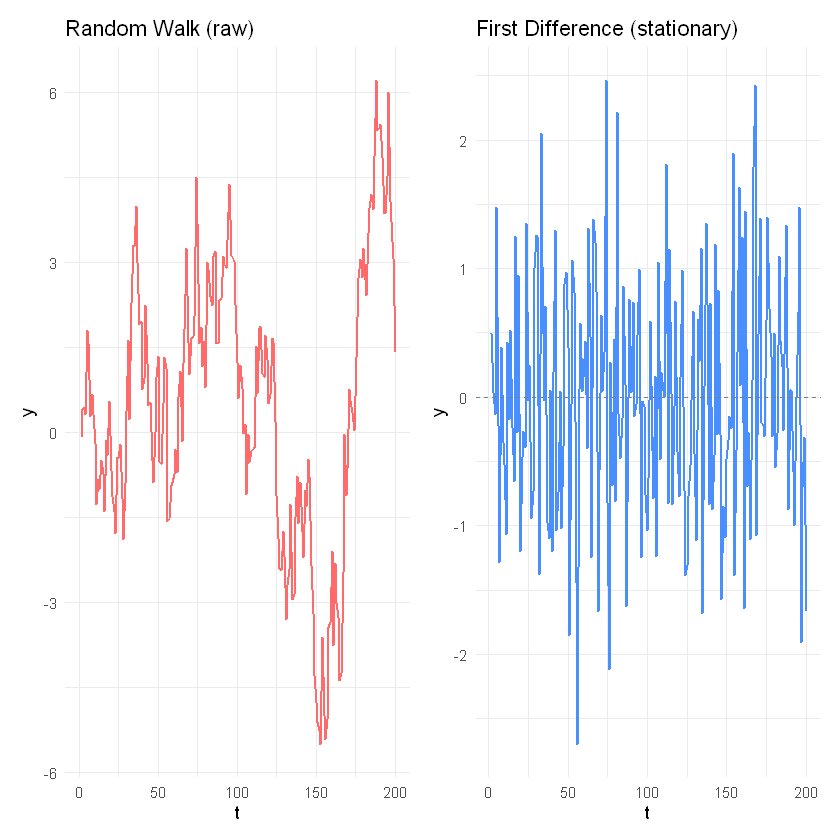

In [4]:
# ── First difference: removes unit root ───────────────────────────────────────
rw_diff1 <- diff(series_rw, differences=1)

p_raw  <- ggplot(tibble(t=t, y=series_rw), aes(x=t, y=y)) +
  geom_line(color="#ff6b6b", linewidth=0.7) +
  labs(title="Random Walk (raw)") + theme_minimal()
p_diff <- ggplot(tibble(t=2:n, y=rw_diff1), aes(x=t, y=y)) +
  geom_line(color="#4a8fff", linewidth=0.7) +
  geom_hline(yintercept=0, linetype="dashed", color="gray50") +
  labs(title="First Difference (stationary)") + theme_minimal()
(p_raw | p_diff)

# ── Verify stationarity after differencing ────────────────────────────────────
cat(sprintf("After first difference:\n"))
cat(sprintf("  ADF p  = %.4f  (< 0.05 → stationary)\n",
            tseries::adf.test(rw_diff1)$p.value))
cat(sprintf("  KPSS p = %.4f  (> 0.05 → stationary)\n",
            tseries::kpss.test(rw_diff1)$p.value))

# ── Auto-select differencing order ────────────────────────────────────────────
cat(sprintf("\nndiffs (KPSS): %d regular differences needed\n",
            forecast::ndiffs(series_rw, test="kpss")))
cat(sprintf("nsdiffs (monthly): %d seasonal differences needed\n",
            forecast::nsdiffs(ts(rnorm(120), frequency=12))))

# ── Log transform for variance non-stationarity ───────────────────────────────
# When variance grows with the level, log-transform BEFORE differencing
pos_series  <- exp(0.02*t + arima.sim(list(ar=0.5), n=n))
log_diff    <- diff(log(pos_series))   # log-returns: stabilises variance + removes trend
cat(sprintf("\nLog-differenced: mean=%.4f, var=%.4f (should be near-constant)\n",
            mean(log_diff), var(log_diff)))

---

## Common Pitfalls

**1. Using only one test**  
ADF and KPSS have opposite nulls. Disagreement between them is informative — it often signals trend-stationarity, which requires detrending rather than differencing. Always run both.

**2. Over-differencing**  
Differencing more than necessary introduces MA unit roots and degrades forecast accuracy. If `ndiffs()` returns 1, difference once and re-test — do not continue differencing until the series "looks better".

**3. Differencing a trend-stationary series**  
A series with a deterministic trend becomes stationary after detrending (regression on time), not differencing. Differencing a trend-stationary series induces a spurious MA unit root. Use `ur.df(type="trend")` to distinguish.

**4. Ignoring variance non-stationarity**  
ADF and KPSS test mean-stationarity only. A series can pass both tests while having variance that grows over time. Always inspect the raw plot; apply log transformation before differencing if variance scales with level.

**5. Not checking for seasonal unit roots**  
Monthly or quarterly data may need seasonal differencing in addition to regular differencing. Use `nsdiffs()` to check before fitting SARIMA.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*